# Cell Envelope: Noise-robust model training, and ancestral phenotype prediction

This notebook provides a pipeline for training noise ribust models and apply them for ancestral phenotype prediction.

### 1. Read train/test/validation datasets

In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from utils.utils import read_diderm_data, pca_run_and_plot, tsne_plot

TAX_LEVEL = "phylum" # <----------------- taxonomy level for train/test split is here!!
DATA_DIRECTORY = "data_diderm"  # <-------- input data directory is here!!
NUM_SPLITS_TO_READ = 30  # <-------------- number of splits to read and process is here!!

RANDOM_SEED = 42
OUTPUT_DIRECTORY = f"../{DATA_DIRECTORY}/outputs/{TAX_LEVEL}"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Create the output directory if doesn't exist
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

In [3]:
# Read train/test/validation splits
from collections import defaultdict

all_splits_dict = defaultdict(int)
for split_id in range(NUM_SPLITS_TO_READ):
    # Read train data
    data_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_train = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/train_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None
    
    X_val_train = torch.load(data_filename_train)
    y_label_train = torch.load(y_filename_train)
    with open(taxa_names_filename_train, "r") as f:
        taxa_group_names_train = [line.strip() for line in f]

    # Read validation data
    data_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_val = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/val_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None

    X_val_val = torch.load(data_filename_val)
    y_label_val = torch.load(y_filename_val)
    with open(taxa_names_filename_val, "r") as f:
        taxa_group_names_val = [line.strip() for line in f]

    # Read test data
    data_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_data_{TAX_LEVEL}_split_{split_id}"
    y_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_annot_{TAX_LEVEL}_split_{split_id}"
    taxa_names_filename_test = f"../{DATA_DIRECTORY}/input_data_train_val_test/{TAX_LEVEL}/test_taxa_{TAX_LEVEL}_split_{split_id}" if TAX_LEVEL != "random" else None

    X_val_test = torch.load(data_filename_test)
    y_label_test = torch.load(y_filename_test)
    with open(taxa_names_filename_test, "r") as f:
        taxa_group_names_test = [line.strip() for line in f]
    
    if sum(y_label_train)/len(y_label_train) < 0.01 or  sum(y_label_test)/len(y_label_test) < 0.01:
        print(f"Skipping split_id = {split_id}")
        continue

    if TAX_LEVEL == "random":
        taxa_group_names_train = None
        taxa_group_names_test = None

    if X_val_train is not None and y_label_train is not None and X_val_test is not None and y_label_test is not None and X_val_val is not None and y_label_val is not None:
        curr_split_dict = defaultdict(str)
        curr_split_dict["X_train"] = X_val_train
        curr_split_dict["y_train"] = y_label_train
        curr_split_dict["taxa_group_names_train"] = taxa_group_names_train
        
        curr_split_dict["X_test"] = X_val_test
        curr_split_dict["y_test"] = y_label_test
        curr_split_dict["taxa_group_names_test"] = taxa_group_names_test
        
        curr_split_dict["X_val"] = X_val_val
        curr_split_dict["y_val"] = y_label_val
        curr_split_dict["taxa_group_names_val"] = taxa_group_names_val

        all_splits_dict[split_id] = curr_split_dict

print(f"Number of added splits = {len(all_splits_dict.keys())}")            

Number of added splits = 30


### 2. Noize tolerance of the original model (trained on the original train data sets)

In [4]:
import joblib
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline

# Train and save models for each data split
trained_models = {}
for split_id in tqdm(all_splits_dict.keys(), desc="Training splits"):
    X_val_train = all_splits_dict[split_id]["X_train"]
    y_label_train = all_splits_dict[split_id]["y_train"]

    pipe = make_pipeline(
        make_pipeline(XGBClassifier(n_jobs=THREADS if DEVICE == "cpu" else None, tree_method="gpu_hist" if DEVICE == "cpu" else "hist"))
    )

    pipe.fit(X_val_train.cpu(), y_label_train.cpu())
    trained_models[split_id] = pipe

Training splits: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:05<00:00,  5.44it/s]


In [5]:
# Evaluate the trained models accuracies on noisy test data

from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data, plot_one_accur_measure

cog_remov_add_accuracies_orig_models = eval_trained_models_on_noisy_data(all_splits_dict, trained_models, hard_fn_flag = True)#, test_or_val = "test")

In [6]:
# Create the output directory for plots if it doesn't exist yet
if not os.path.exists(f"{OUTPUT_DIRECTORY}/plots"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/plots")

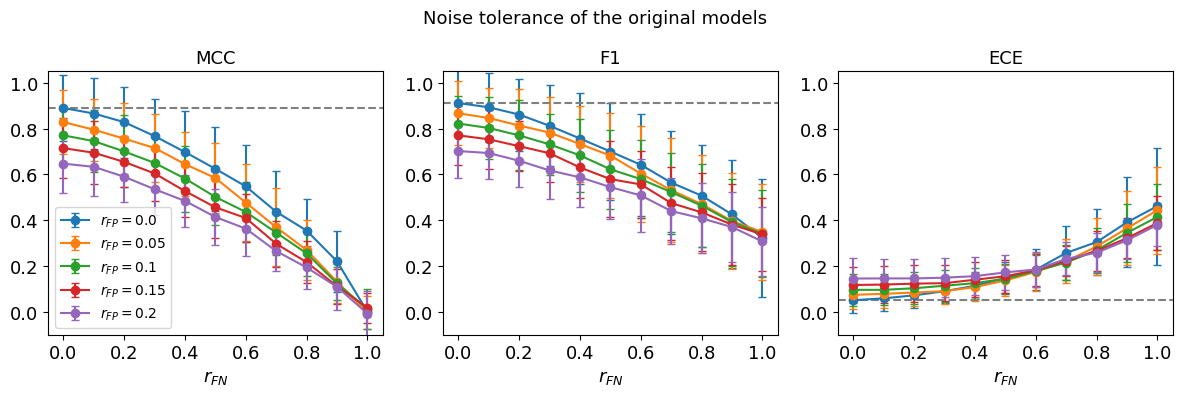

In [7]:
# Visualize the results

FONTSIZE = 13

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = [
    ("mcc", "MCC"),
    ("f1", "F1"),
    ("ece", "ECE"),
]

for ax, (metric, title) in zip(axes, metrics):

    plot_one_accur_measure(
        ax,
        metric,
        cog_remov_add_accuracies_orig_models,
        fontsize=FONTSIZE,
    )

    ax.axhline(
        y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)][metric][0],
        color="grey",
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_ylim([-0.1, 1.05])
    ax.set_title(title, fontsize=FONTSIZE)

axes[0].legend()

plt.suptitle(
    "Noise tolerance of the original models",
    fontsize=FONTSIZE,
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.savefig(
    f"{OUTPUT_DIRECTORY}/plots/noise_toler_orig_models.svg",
    format="svg",
    bbox_inches="tight",
)

plt.show()

### 3. Noise tolerance of the models trained on noisy data

Here we train the original models for each train/test split and explore their performance on the noisy test data. The noise on the test dataset is implemented as the fraction false positives and false negatives.

In [8]:
# Create output directories for the trained models

TRAINED_MOD_DIR = "trained_models_train_val_test"
if not os.path.exists(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}"):
    os.makedirs(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}")

#### 3.1 Analyze performance of the models on the high noise range [min_fp, max_fp], [min_fn, max_fn]

Processing noise types:   0%|                                                                                             | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|████████████████████████████▎                                                        | 1/3 [00:01<00:03,  1.96s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|████████████████████████████████████████████████████████▋                            | 2/3 [00:04<00:02,  2.19s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:07<00:00,  2.41s/it]


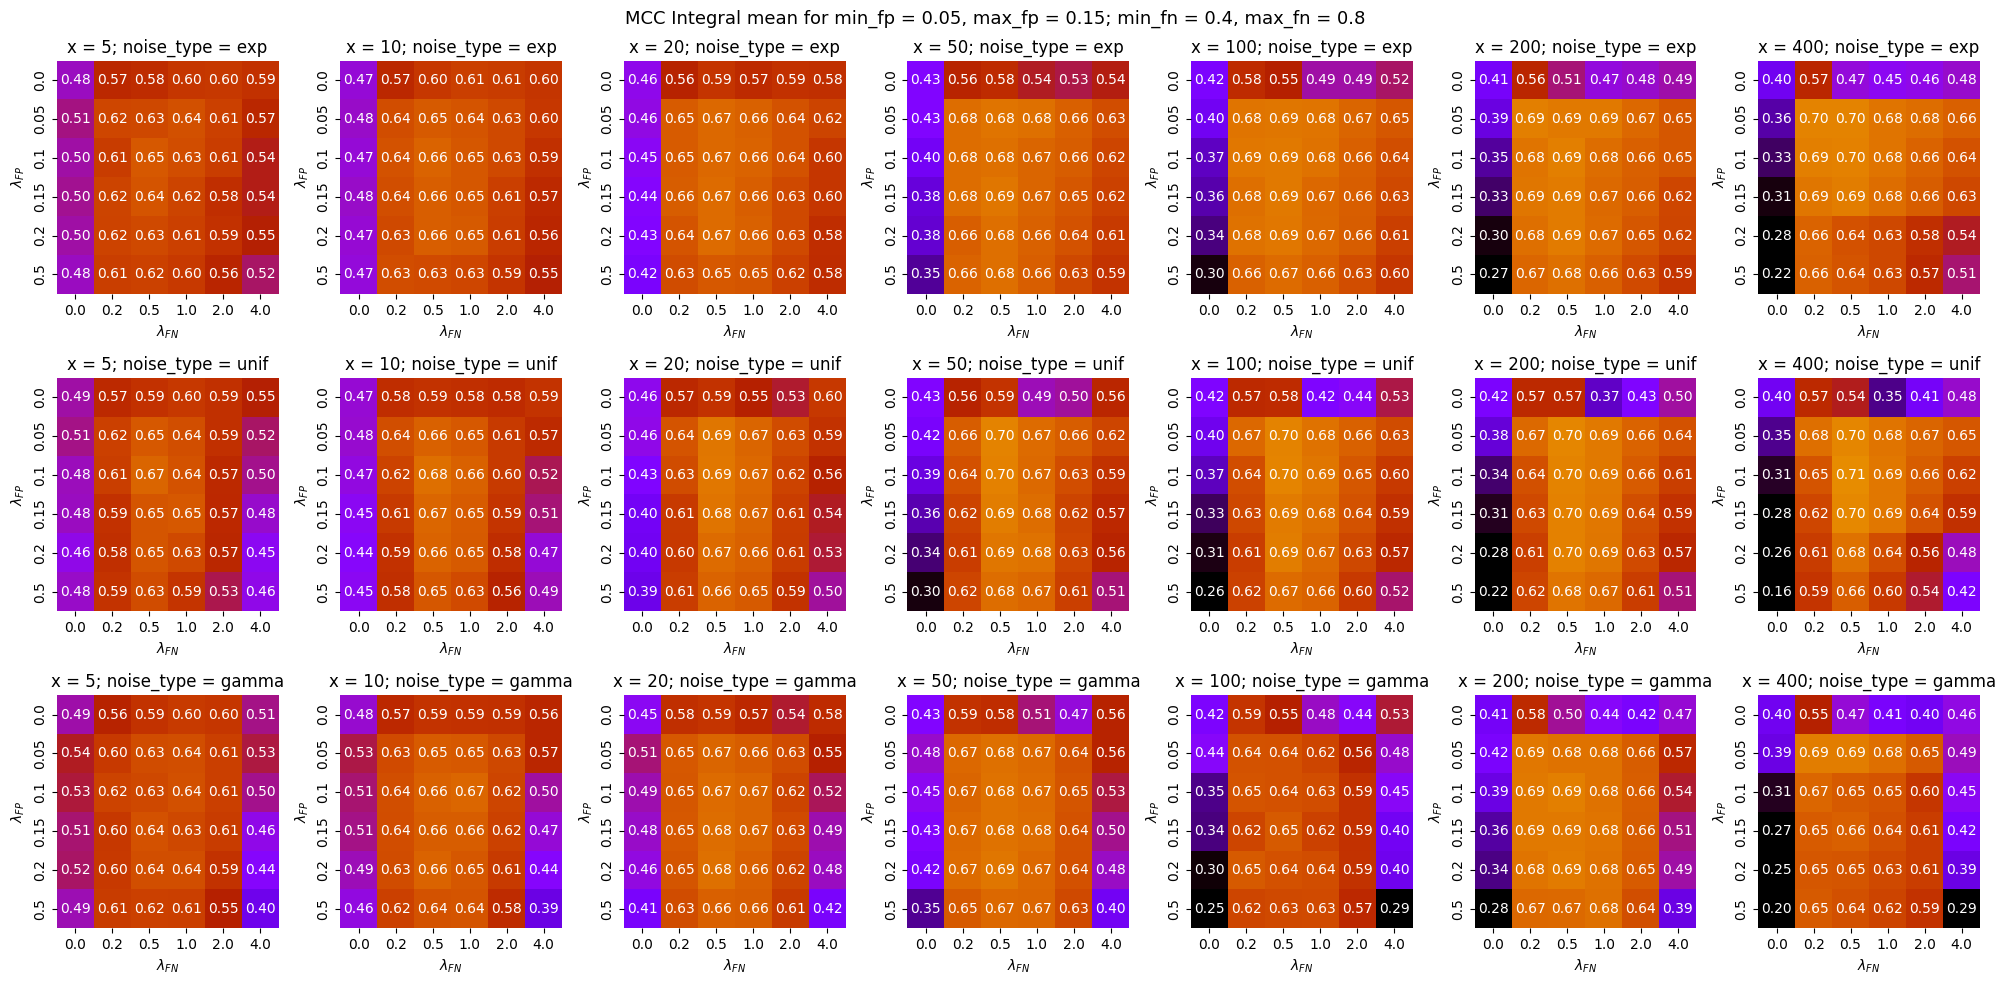

In [9]:
# Find the integrals of the MCC curves calculated for models trained on diffrent noise ranges and fisualize the result

from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data, fp_curve_areas_one_model, fp_fn_surface_integral, plot_model_groups_surf_int

# Specify the noise range for the test data
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]

# Specify the min and max noise ranges for the test data (the ranges for which the integrals will be calculated)
min_fn = 0.4
max_fn = 0.8

min_fp = 0.05
max_fp = 0.15

# Specify the paraters of the models trained on noise augmented data
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

# Calculate the integrals for each trained model and visualize the result
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_mcc_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'mcc'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.3, vmax=0.8, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"MCC Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/mcc_integral_actoss_noise.svg", format="svg", bbox_inches='tight') #<-------save as pdf
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/mcc_integral_actoss_noise.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

Processing noise types:   0%|                                                                                             | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|████████████████████████████▎                                                        | 1/3 [00:01<00:03,  1.96s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|████████████████████████████████████████████████████████▋                            | 2/3 [00:05<00:02,  2.79s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:09<00:00,  3.08s/it]


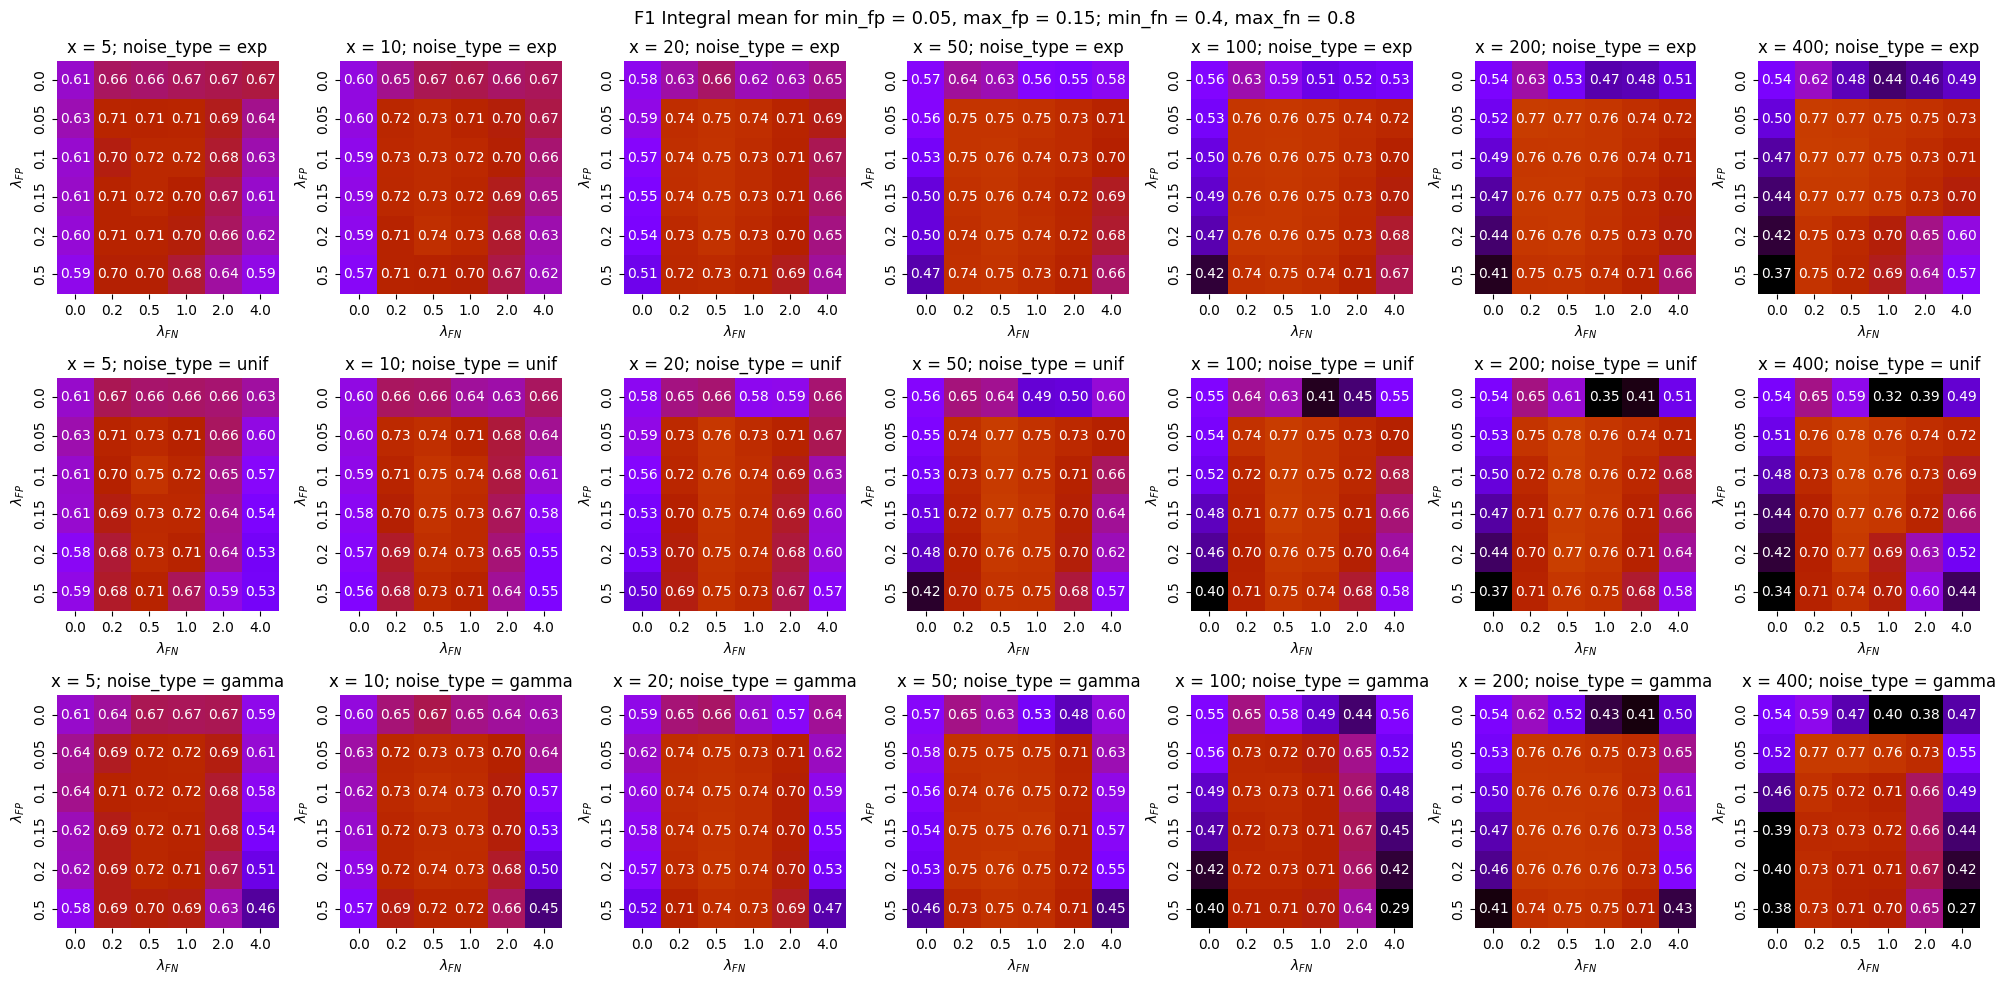

In [10]:
# Find the integrals of the F1 curves calculated for models trained on diffrent noise ranges and fisualize the result

# Specify the noise range for the test data
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]

# Specify the min and max noise ranges for the test data (the ranges for which the integrals will be calculated)
min_fn = 0.4
max_fn = 0.8

min_fp = 0.05
max_fp = 0.15

# Specify the paraters of the models trained on noise augmented data
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

# Calculate the integrals for each trained model and visualize the result
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_f1_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'f1'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.4, vmax=1.0, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"F1 Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/f1_integral_actoss_noise.svg", format="svg", bbox_inches='tight') #<-------save as pdf
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/f1_integral_actoss_noise.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

In [11]:
f"{OUTPUT_DIRECTORY}/plots/brier_integral_actoss_noise.svg"

'../data_diderm/outputs/phylum/plots/brier_integral_actoss_noise.svg'

Processing noise types:   0%|                                                                                             | 0/3 [00:00<?, ?it/s]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  33%|████████████████████████████▎                                                        | 1/3 [00:01<00:03,  1.94s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types:  67%|████████████████████████████████████████████████████████▋                            | 2/3 [00:04<00:02,  2.19s/it]

Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...
Loading the existing dict...


Processing noise types: 100%|█████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:07<00:00,  2.40s/it]


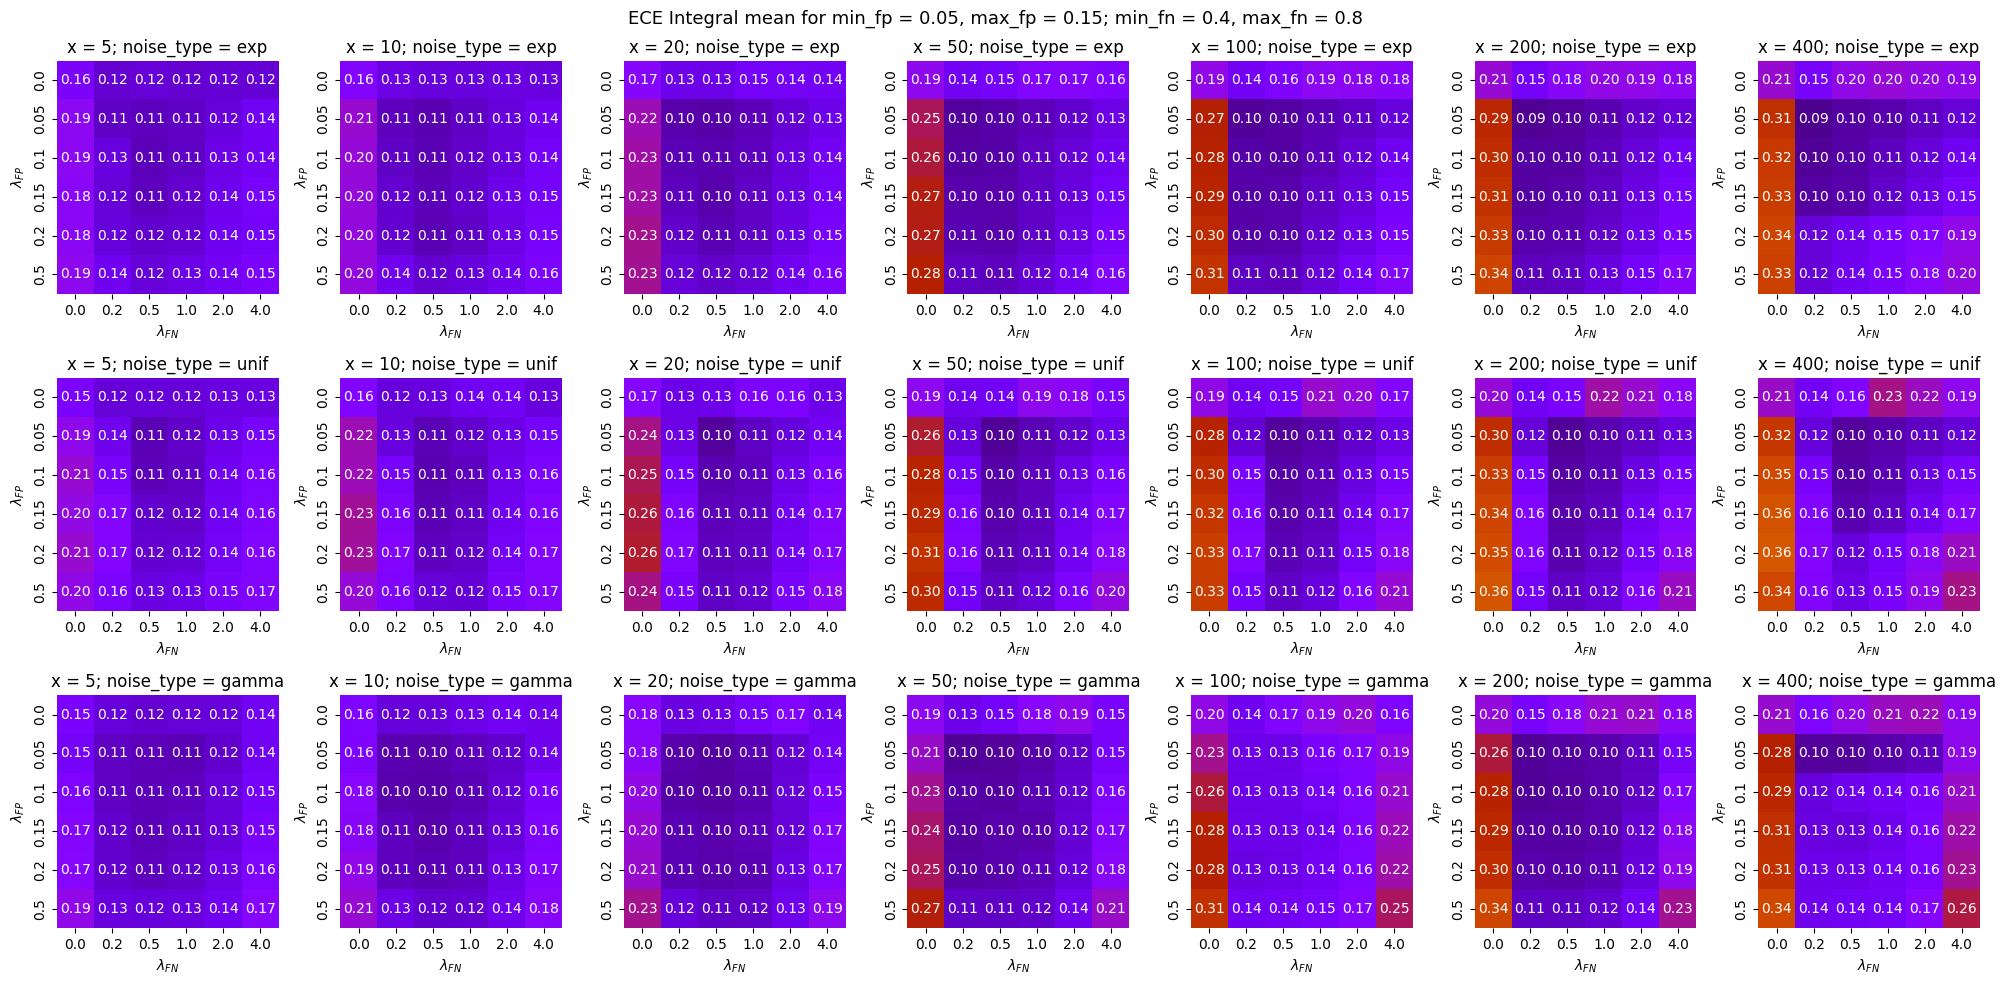

In [12]:
# Find the integrals of the ECE curves calculated for models trained on diffrent noise ranges and fisualize the result

# Specify the noise range for the test data
fn_rate_arr = [0.0, 0.2, 0.5, 1.0, 2.0, 4.0]
fp_rate_arr = [0.0, 0.05, 0.1, 0.15, 0.2, 0.5]
mean_rem_add_rates_tuples = [(add, rem) for add in fp_rate_arr for rem in fn_rate_arr]

# Specify the min and max noise ranges for the test data (the ranges for which the integrals will be calculated)
min_fn = 0.4
max_fn = 0.8

min_fp = 0.05
max_fp = 0.15

# Specify the paraters of the models trained on noise augmented data
x_range = [5, 10, 20, 50, 100, 200, 400]
noise_type_range = ["exp", "unif", "gamma"]

# Calculate the integrals for each trained model and visualize the result
fig, axes = plt.subplots(len(noise_type_range), len(x_range), figsize=(20,10))
for i, noise_type in enumerate(tqdm(noise_type_range, desc="Processing noise types")):
    for j, x in enumerate(x_range):
        ax = axes[i][j]
        filename_curve_dict = f"surf_area_ece_integrals_min_fp_{min_fp}_max_fp_{max_fp}_min_fn_{min_fn}_max_fn_{max_fn}_noise_type_{noise_type}_x_{x}.pkl" 
        filepath = f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename_curve_dict}"

        if os.path.exists(filepath):
            print("Loading the existing dict...")
            one_accur_dict = joblib.load(filepath)
        else:
            one_accur_dict = defaultdict(list)
            for fp_fn_tuple in mean_rem_add_rates_tuples:
                # Load the model
                filename = f"trained_models_fp_{fp_fn_tuple[0]}_fn_{fp_fn_tuple[1]}_noise_type_{noise_type}_x_{x}.pkl"
                loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")
                cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, min_fp = min_fp, min_fn = min_fn, max_fp = max_fp, max_fn = max_fn, test_or_val = "val")
    
                # Find the FP curves integrals on range [max_fp, max_fn]
                metric = 'ece'
                fp_surface_integral = fp_fn_surface_integral(metric, min_fp, max_fp, min_fn, max_fn, cog_remov_add_accuracies)#fp_curve_areas_one_model(metric, max_fp, max_fn, cog_remov_add_accuracies)      
                one_accur_dict[fp_fn_tuple] = fp_surface_integral

            joblib.dump(one_accur_dict, filepath)
            print("Saving the dict...")

        plot_model_groups_surf_int(one_accur_dict, ax, vmin=0.05, vmax=0.5, cmap="gnuplot")
        ax.set_title(f"x = {x}; noise_type = {noise_type}")
        ax.set_xlabel(r"$\lambda_{FN}$")
        ax.set_ylabel(r"$\lambda_{FP}$")

plt.suptitle(rf"ECE Integral mean for min_fp = {min_fp}, max_fp = {max_fp}; min_fn = {min_fn}, max_fn = {max_fn}", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/ece_integral_actoss_noise.svg", format="svg", bbox_inches='tight') #<-------save as pdf
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/ece_integral_actoss_noise.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

#### 3.2  Visualize the performance improvement for the chosen model

In [13]:
# Choose a model
x_noisy_samples = 100
fp_rate_mean = 0.1# 0.05
fn_rate_mean = 0.5#0.5
noise_type = "exp"

# Load a pre-trained model
filename = f"trained_models_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x_noisy_samples}.pkl"
loaded_models_dict = joblib.load(f"{OUTPUT_DIRECTORY}/{TRAINED_MOD_DIR}/{filename}")

In [14]:
from utils.utils_ancestral_predict import eval_trained_models_on_noisy_data
cog_remov_add_accuracies = eval_trained_models_on_noisy_data(all_splits_dict, loaded_models_dict, hard_fn_flag = True, max_fp = 0.2, max_fn = 1, test_or_val = "test")

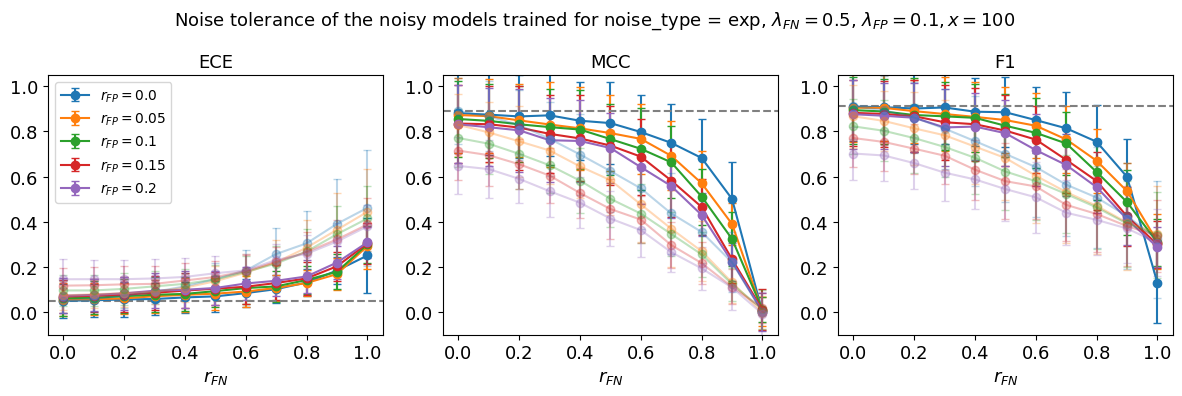

In [15]:
import matplotlib.pyplot as plt
import numpy as np

FONTSIZE=13

fig, axes = plt.subplots(1,3, figsize=(12,4))

plt.subplot(1, 3, 1)
plot_one_accur_measure(axes[0], "ece", cog_remov_add_accuracies)
axes[0].legend()
plot_one_accur_measure(axes[0], "ece", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[0].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['ece'][0], color='grey', linestyle='--', linewidth=1.5)
axes[0].set_ylim([-0.1,1.05])
axes[0].set_title("ECE", fontsize=FONTSIZE)


plt.subplot(1, 3, 2)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies)
plot_one_accur_measure(axes[1], "mcc", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[1].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['mcc'][0], color='grey', linestyle='--', linewidth=1.5)
axes[1].set_ylim([-0.1,1.05])
axes[1].set_title("MCC", fontsize=FONTSIZE)

plt.subplot(1, 3, 3)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies)
plot_one_accur_measure(axes[2], "f1", cog_remov_add_accuracies_orig_models, alpha=0.3)
axes[2].axhline(y=cog_remov_add_accuracies_orig_models[(0.0, 0.0)]['f1'][0], color='grey', linestyle='--', linewidth=1.5)
axes[2].set_ylim([-0.1,1.05])
axes[2].set_title("F1", fontsize=FONTSIZE)

plt.suptitle(f"Noise tolerance of the noisy models trained for noise_type = {noise_type}, $\lambda_{{FN}} = {fn_rate_mean}$, $\lambda_{{FP}} = {fp_rate_mean}, x = {x_noisy_samples}$", fontsize=FONTSIZE)
plt.tight_layout()

plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}.svg", format="svg", bbox_inches='tight')
plt.savefig(f"{OUTPUT_DIRECTORY}/plots/noise_toler_noisy_model_FP_{fp_rate_mean}_FN_{fn_rate_mean}_x_{x_noisy_samples}.pdf", format="pdf", bbox_inches='tight') #<-------save as pdf

### 4.  Ancestral phenotype prediction

In [16]:
# Read the annotated count table and get the list of COGs from there
df_data = pd.read_csv("../data_diderm/all_gene_annotations.tsv", sep="\t")
X_column_names = df_data.columns[df_data.columns.str.startswith("COG")].tolist()

In [17]:
# Read the GTDB tables for the genome taxonomy

import polars as pl

BAC_TSV = '../data_preparation/gtdb_files/bac120_metadata_r202.tsv'
ARC_TSV = '../data_preparation/gtdb_files/ar122_metadata_r202.tsv'

tax_level = "phylum"
tax_levels = {"domain": 0, "phylum": 1, "class": 2, "order": 3, "family": 4}

gtdb_df = pl.concat([pl.read_csv(BAC_TSV, separator="\t"),
    pl.read_csv(ARC_TSV, separator="\t")])
gtdb_df = gtdb_df[['accession', "gtdb_taxonomy"]]
for key in tax_levels.keys():
    tax_level = tax_levels[key]
    gtdb_df = gtdb_df.with_columns(pl.col("gtdb_taxonomy").str.split(';').list.get(tax_levels[key]).alias(key))
gtdb_df = gtdb_df.drop("gtdb_taxonomy")
#gtdb_df = gtdb_df[['accession', tax_level]]
gtdb_df = gtdb_df.to_pandas()

In [18]:
# Get the species tree leaf node names

leaves_acc_names = pd.read_csv("../ancestral_data/GenomesInfo.csv", sep=",")
columns_to_keep = ['accession', 'ShortCode']
leaves_acc_names = leaves_acc_names[columns_to_keep]
leaves_acc_names

,accession,ShortCode
0,GB_GCA_003599535.1,AABM5X1
1,GB_GCA_005223185.1,AABM5X2
2,GB_GCA_002127415.1,AABM5X3
3,GB_GCA_003598085.1,Abys1
4,GB_GCA_003223555.1,Acid1
...,...,...
1002,GB_GCA_001775395.1,Zixi1
1003,GB_GCA_002791595.1,Zixi2
1004,GB_GCA_003105265.1,Zixi3
1005,GB_GCA_002838945.1,Zixi4


In [19]:
leave_nodes_with_taxonomy = pd.merge(leaves_acc_names, gtdb_df, on="accession", how="inner")
leave_nodes_with_taxonomy

,accession,ShortCode,domain,phylum,class,order,family
0,GB_GCA_003599535.1,AABM5X1,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
1,GB_GCA_005223185.1,AABM5X2,d__Bacteria,p__AABM5-125-24,c__B3-LCP,o__B3-LCP,f__B3-LCP
2,GB_GCA_002127415.1,AABM5X3,d__Bacteria,p__AABM5-125-24,c__AABM5-125-24,o__AABM5-125-24,f__AABM5-125-24
3,GB_GCA_003598085.1,Abys1,d__Bacteria,p__Abyssubacteria,c__SURF-5,o__SURF-5,f__SURF-5
4,GB_GCA_003223555.1,Acid1,d__Bacteria,p__Acidobacteriota,c__Vicinamibacteria,o__Fen-336,f__Fen-336
...,...,...,...,...,...,...,...
992,GB_GCA_001775395.1,Zixi1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UBA10806,f__UBA10806
993,GB_GCA_002791595.1,Zixi2,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UM-FILTER-46-8,f__UM-FILTER-46-8
994,GB_GCA_003105265.1,Zixi3,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__FEB-12
995,GB_GCA_002838945.1,Zixi4,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__GN15,f__PGXB01


In [20]:
# Read the tree file and pivot it into a COG count table

df = pd.read_csv('../ancestral_data/TableAncestralRoot1_aggregated_byCOG.tsv', sep='\t', dtype={'column_name': str})
df = df.T

df.columns = df.loc['COG']
df = df.drop(index='COG')
df.columns.name = None

pivot_df = df.apply(pd.to_numeric)
pivot_df.index = pivot_df.index.str.replace(r'\(\d+\)$', '', regex=True)

pivot_df

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0010,COG0012,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
AABM5X1,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X2,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
AABM5X3,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Abys1,1.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
Acid1,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,0.55,0.58,0.76,0.37,1.00,0.01,0.12,1.00,1.00,0.23,...,0.01,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2009,0.26,0.38,0.09,0.31,0.91,0.00,0.24,0.68,0.08,1.00,...,0.02,0.0,0.00,0.0,0.02,0.0,0.0,0.0,0.09,0.0
2010,0.24,0.51,0.91,0.13,0.70,0.00,0.06,1.00,0.68,0.15,...,0.01,0.0,0.03,0.0,0.00,0.0,0.0,0.0,0.01,0.0
2011,0.08,0.07,0.14,0.08,0.29,0.00,0.05,0.88,0.23,0.13,...,0.00,0.0,0.01,0.0,0.00,0.0,0.0,0.0,0.00,0.0


In [21]:
# Optionally: threshold the COG count values to convert them to 0/1s
threshold = 0.04
pivot_df = pivot_df.applymap(lambda x: 0 if x <= threshold else max(x, 1))
pivot_df

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0006,COG0007,COG0008,COG0010,COG0012,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
AABM5X1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AABM5X2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AABM5X3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Abys1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Acid1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2010,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Find COGs that are in the intersection between the COG set from the species tree and the COGs from the annotated data
cogs_from_mastertable = list(pivot_df.columns)
cogs_intersect = list(set(cogs_from_mastertable) & set(X_column_names))
cogs_intersect = sorted(cogs_intersect, key=lambda x: int(x[3:]))

# Apply the intersection COGs to the species tree count table
tree_nodes_data = pivot_df[cogs_intersect]
tree_nodes_data

,COG0001,COG0002,COG0003,COG0004,COG0005,COG0007,COG0008,COG0010,COG0012,COG0013,...,COG5611,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663
AABM5X1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AABM5X2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AABM5X3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Abys1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Acid1,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2009,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2010,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
# Prepare model train data

diderm_annot = pd.read_csv("../data_diderm/gold_standard1.tsv", sep="\t")
diderm_cogs = pd.read_csv("../data_diderm/all_gene_annotations.tsv", sep="\t")
merged_tab  = pd.merge(diderm_cogs, diderm_annot, on="accession", how="inner") 
merged_tab

,accession,COG0001,COG0002,COG0003,COG0004,COG0005,COG0007,COG0008,COG0010,COG0012,...,COG5615,COG5621,COG5625,COG5632,COG5640,COG5643,COG5650,COG5652,COG5663,high_throughput_dermy
0,GB_GCA_000018565.1,1,1,1,3,3,0,1,1,1,...,0,0,0,1,1,0,0,0,0,Monoderm
1,GB_GCA_000091165.1,2,1,0,2,1,1,1,0,1,...,0,1,0,0,0,0,0,0,1,Diderm
2,GB_GCA_000252485.1,1,1,2,3,1,1,0,0,1,...,0,0,0,1,0,0,0,0,0,Diderm
3,GB_GCA_000276965.1,1,1,0,3,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,Diderm
4,GB_GCA_000353875.1,1,1,0,1,0,1,2,0,1,...,0,0,0,0,0,0,0,0,0,Diderm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,RS_GCF_900215725.1,0,0,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,Monoderm
924,RS_GCF_900604345.1,0,1,0,1,1,0,1,0,1,...,0,0,0,2,0,0,0,0,0,Monoderm
925,RS_GCF_900626135.1,1,0,0,0,0,1,1,0,1,...,0,0,0,1,0,0,0,1,0,Monoderm
926,RS_GCF_900637055.1,2,1,1,1,0,1,1,1,1,...,0,0,0,3,0,0,0,1,1,Monoderm


In [24]:
# Prepare phenotype annotation vector
y_label_train = torch.tensor(merged_tab["high_throughput_dermy"].map({"Monoderm": 1, "Diderm": 0}).to_numpy(), dtype=torch.long)

numeric_df = merged_tab.iloc[:, 1:-1]
numeric_values = torch.tensor(numeric_df.values, dtype=torch.float32)
numeric_values = (numeric_values> 0).int()  

X_column_names = merged_tab.columns.tolist()[1:-1]
name_to_idx = {name: i for i, name in enumerate(X_column_names)}

# Keep only those in cogs_intersect AND present in X_column_names
keep_indices = [name_to_idx[cog] for cog in cogs_intersect if cog in name_to_idx]

# Filter tensor and column names
X_val_train_filtered = numeric_values[:, keep_indices]
X_column_names_filtered = [X_column_names[i] for i in keep_indices]
X_val_train_filtered.shape

torch.Size([928, 2660])

In [25]:
# Initialize XGBoost for training

device = DEVICE
use_gpu = torch.cuda.is_available()
tree_method = "gpu_hist" if use_gpu else "hist"
predictor = "gpu_predictor" if use_gpu else "auto"

def make_xgb():
    return XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method=tree_method,
        n_jobs=-1
    )

In [26]:
from utils.utils_ancestral_predict import augment_data_with_noise

# Augment X train with the noise 
x = 100
fp_rate_mean = 0.1
fn_rate_mean = 0.5
noise_type = "exp"

X_augmented, y_augmented = augment_data_with_noise(X_val_train_filtered, y_label_train, x, fp_rate_mean, fn_rate_mean, noise_type=noise_type, filename=None)
X_augmented.shape

torch.Size([93728, 2660])

In [27]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline

# Train a model on noise augmented data
pipe = make_pipeline(make_xgb())
pipe.fit(X_augmented.cpu(), y_augmented.cpu());

In [28]:
# Convert tree genomes to a tensor
numeric_df = tree_nodes_data.select_dtypes(include=["number"])
ancestral_nodes_tensor = torch.tensor(numeric_df.to_numpy())

# Apply the trained model to the tree genomes
y_pred_ancestr_nodes = pipe.predict(ancestral_nodes_tensor.cpu())

# Predict the probabilities of each class and find the maximum probability
y_proba_ancestr_nodes = pipe.predict_proba(ancestral_nodes_tensor.cpu())
max_proba = [max(x) for x in y_proba_ancestr_nodes]

In [29]:
# Genrate a table with all genome names from the species tree and the model predictions

# Count for the correctly predicted extant genomes (the ones whose true annotations we know)
correct = 0
total = 0

# Arrays for storing the values for each tree node 
oxytolerance = []        # predicted phenotype label
annot_vs_pred_label = [] # a label indicating wheather the genome's label was predicted by the model or already annotaed  

tree_node_names_list = tree_nodes_data.index.tolist()
merged_df = pd.merge(diderm_annot, leaves_acc_names, on="accession", how="left")
merged_df = merged_df.rename(columns={"high_throughput_dermy": "didermy"})

# Iterate over all nodes in the species tree 
for idx, node in enumerate(tree_node_names_list):
    if node in list(merged_df['ShortCode']):
        
        oxytol = merged_df.loc[merged_df["ShortCode"] == node, "didermy"]
        oxytolerance.append(oxytol.iloc[0])
        annot_vs_pred_label.append("annot")

        # Count the number or correctly predicted extant genomes
        if (oxytol.iloc[0] == "Monoderm" and y_pred_ancestr_nodes[idx] == 1) or (oxytol.iloc[0] == "Diderm" and y_pred_ancestr_nodes[idx] == 0):
            correct += 1
        total +=1    
        
    else:
        annot_vs_pred_label.append("predict")
        oxytolerance.append("Monoderm" if y_pred_ancestr_nodes[idx] == 1 else "Diderm")  #map({'Diderm': 0, 'Monoderm': 1})

# Generate the final table
df_pred = pd.DataFrame({
    'NodeName': tree_node_names_list,
    'didermy': oxytolerance,
    'annot_or_predict':annot_vs_pred_label,
    'max_proba': max_proba,
    "proba_and_uncert": y_proba_ancestr_nodes[:, 1]
})

print(f"Correct predict = {correct} of {total}; which is {correct/total}")

Correct predict = 912 of 912; which is 1.0


In [30]:
# Print the prediction results for the root node
print(df_pred.loc[df_pred["NodeName"] == '2012', "didermy"].iloc[0])
print(df_pred.loc[df_pred["NodeName"] == '2012', "max_proba"].iloc[0])

Diderm
0.8815472


In [31]:
# Create and save a tree file with all the model prediction labels

from Bio import Phylo
from utils.utils_ancestral_predict import process_res

# Read the already existing tree file that we annotate with the model predictions below 
tree = Phylo.read("../ancestral_data/C65.tree", "newick")

# The names of important COGs for the phenotype
cog_names = ['COG0763', 'COG5009', 'COG0751', 'COG0751', 'COG0795']

for clade in tree.find_clades(order="level"):
    node_name = clade.name if clade.name is not None else str(clade.confidence)

    # Generate the model prediction comments for the tree file
    oxytol_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "didermy"])
    predict_annot_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "annot_or_predict"])
    max_proba_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "max_proba"])
    max_proba_comm = str(round(float(max_proba_comm), 2)) if max_proba_comm != '' else ''
    
    proba_and_uncert_comm = process_res(df_pred.loc[df_pred["NodeName"] == node_name, "proba_and_uncert"])
    proba_and_uncert_comm = str(round(float(proba_and_uncert_comm), 2)) if proba_and_uncert_comm != '' else ''
    
    if oxytol_comm == "Monoderm":
        color = "#9467bd"  # tab:purple
    else:
        color = "#2ca02c"  # tab:green

    comment_str = f'&!color={color}, didermy={oxytol_comm}, predict_annot={predict_annot_comm},max_proba={max_proba_comm},proba_and_uncert = {proba_and_uncert_comm}'#,,{cog_name}={str(cog_count)}'     

    for cog_name in cog_names:
        cog_count = int(pivot_df.loc[node_name, cog_name]) if cog_name in pivot_df.columns else -1  
        if cog_count > 1:
            cog_count = 1
        comment_str += f',{cog_name}={str(cog_count)}'
    
    clade.comment = comment_str

# Save the tree file with all annotations
filename =   f"../ancestral_data/diderm_C65_annotated_on_noisy_train_fp_{fp_rate_mean}_fn_{fn_rate_mean}_noise_type_{noise_type}_x_{x}_ancRootTable_threshold_{threshold}.tree"  
Phylo.write(tree, filename, "nexus")

1